# Lab8
## Setup for SUSY dataset
Use the SUSY for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn
Scikit-learn is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA).

## Exercise 1: Install Scikit-Learn
Follow the Installation Instructions and install scikit-learn in your environment.

In [3]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 11.4 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.2 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /home/harukazambeck/.local/share/pipx/venvs/notebook/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Exercise 2: Read About Classifiers
**Part a**
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through scikit-learn's documentation. You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of classification algorithms.

**Part b**
Note scikit-learn's documentation is rather comprehensive. The documentation on linear models shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

**Part c**
Read through the LDA Documentation.

## Exercise 3: Training a Classifier
Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

- Define the inputs (X) vs outputs (Y)
- Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]

We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


LinearDiscriminantAnalysis()
**In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**
We can plot the output, comparing signal and background:

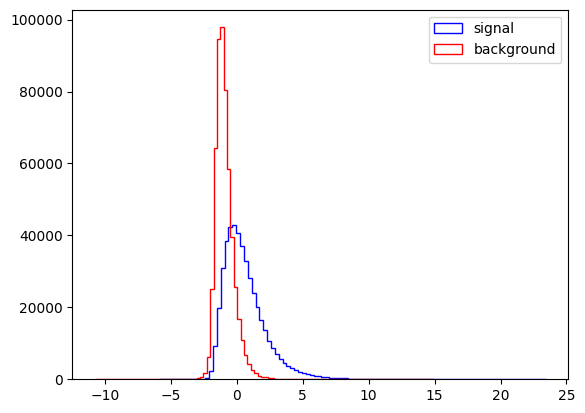

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

## Part A


Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

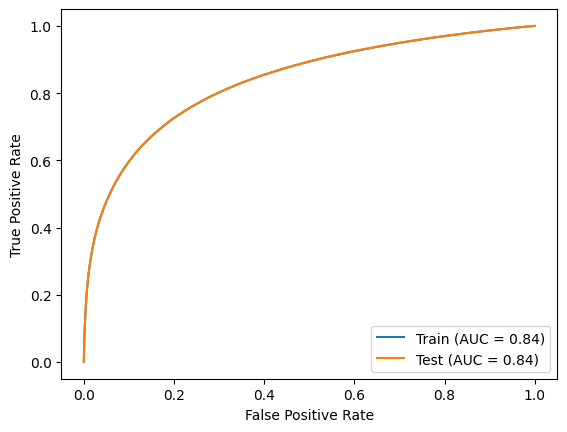

In [7]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.2f})")
plt.plot(fpr,  tpr,  label=f"Test (AUC = {roc_auc:.2f})")

plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

## Part B ##


Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot.

In [11]:
print(Train_Sample.columns)

Index(['signal', 'l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'],
      dtype='str')


In [14]:
features = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']

X_train = Train_Sample[features]
y_train = Train_Sample['signal']

X_test = Test_Sample[features]
y_test = Test_Sample['signal']

train_scores = Fisher.decision_function(X_train)
test_scores = Fisher.decision_function(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, train_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

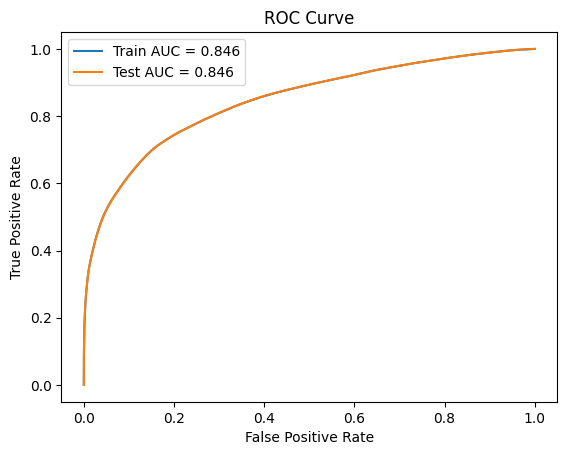

In [30]:
plt.figure()

plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc_train:.3f}')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc_test:.3f}')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")

plt.show()

## Exercise 4: Comparing Techniques

Part a

Select 3 different classifiers from the techniques listed here to compare. Note that you can use the multi-layer perception to build a deep network, though training may be prohibitively slow. So avoid this technique.

Part b

Write a funtion that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

Part c

Use the best method from part c to compute the maximal significance for the scenario in lab 5.

In [18]:
## part a
## Logistic Regression, Decision Tree, Random Forest

In [22]:
## part b
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [33]:
X_train = Train_Sample[features]
y_train = Train_Sample['signal']

X_test = Test_Sample[features]
y_test = Test_Sample['signal']

## decision_function -> predict_proba. 
## chatgpt debugged
train_scores = rf.predict_proba(X_train)[:,1]
test_scores = rf.predict_proba(X_test)[:,1]

fpr_train, tpr_train, _ = roc_curve(y_train, train_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

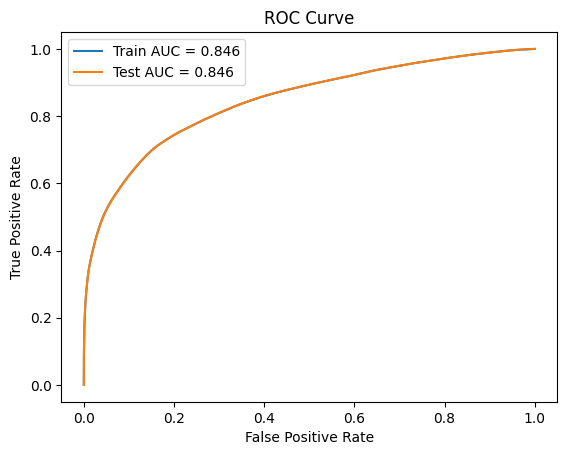

In [34]:
plt.figure()

plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc_train:.3f}')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc_test:.3f}')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")

plt.show()

## Exercise 5:  Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

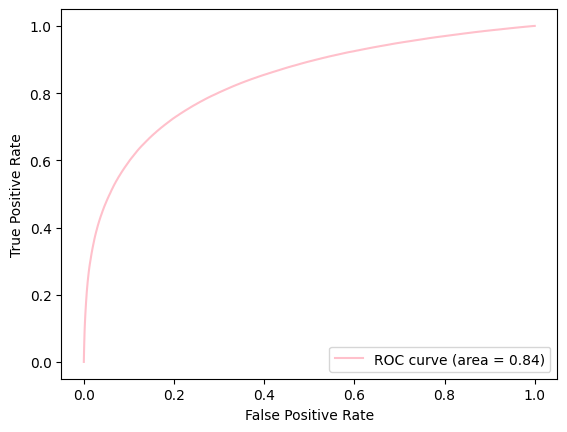

In [32]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='pink', label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

Part a

TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about Precision and Recall, Accuracy, and F-score

Precision and Recall -Precision = relevant retrieved instances/ all retrieved instances, how close measurements are to each other


                    - Recall = "/All relavant instances

                    
Accuracy -how close measurements is to true value


F-score - measure of predictive performance. Calculated from precision and recall. 2(precision*recall/precision+recall)

Part b

Using scikit-learn tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance.

In [47]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
y_score = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_score)

In [38]:
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , ..., 0.99947579, 0.99949056,
        1.        ], shape=(322073,)),
 array([0.00000000e+00, 2.18229591e-06, 6.54688772e-06, ...,
        9.99984724e-01, 9.99984724e-01, 1.00000000e+00], shape=(322073,)),
 array([       inf, 0.9880421 , 0.98795159, ..., 0.15322779, 0.15302859,
        0.15285857], shape=(322073,)))

In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_score)

In [49]:
precision

0.8195785622332137

In [50]:
recall

0.6599350112279124

In [51]:
f1

0.7311437993829847

In [55]:
accuracy

0.7776

In [59]:
auc

0.8456831946104113

In [66]:
table = [
    ["FPR" , fpr],
    ["tpr" , tpr],
    ["AUC", auc],
    ["Precision", precision],
    ["Recall", recall],
    ["F1 Score", f1],
    ["Accuracy", accuracy]
]

In [67]:
print(tabulate.tabulate(table, headers=["Metric", "Value"]))

Metric     Value
---------  -----------------------------------------------------------------------
FPR        [0.         0.         0.         ... 0.99947579 0.99949056 1.        ]
tpr        [0.00000000e+00 2.18229591e-06 6.54688772e-06 ... 9.99984724e-01
            9.99984724e-01 1.00000000e+00]
AUC        0.8456831946104113
Precision  0.8195785622332137
Recall     0.6599350112279124
F1 Score   0.7311437993829847
Accuracy   0.7776
